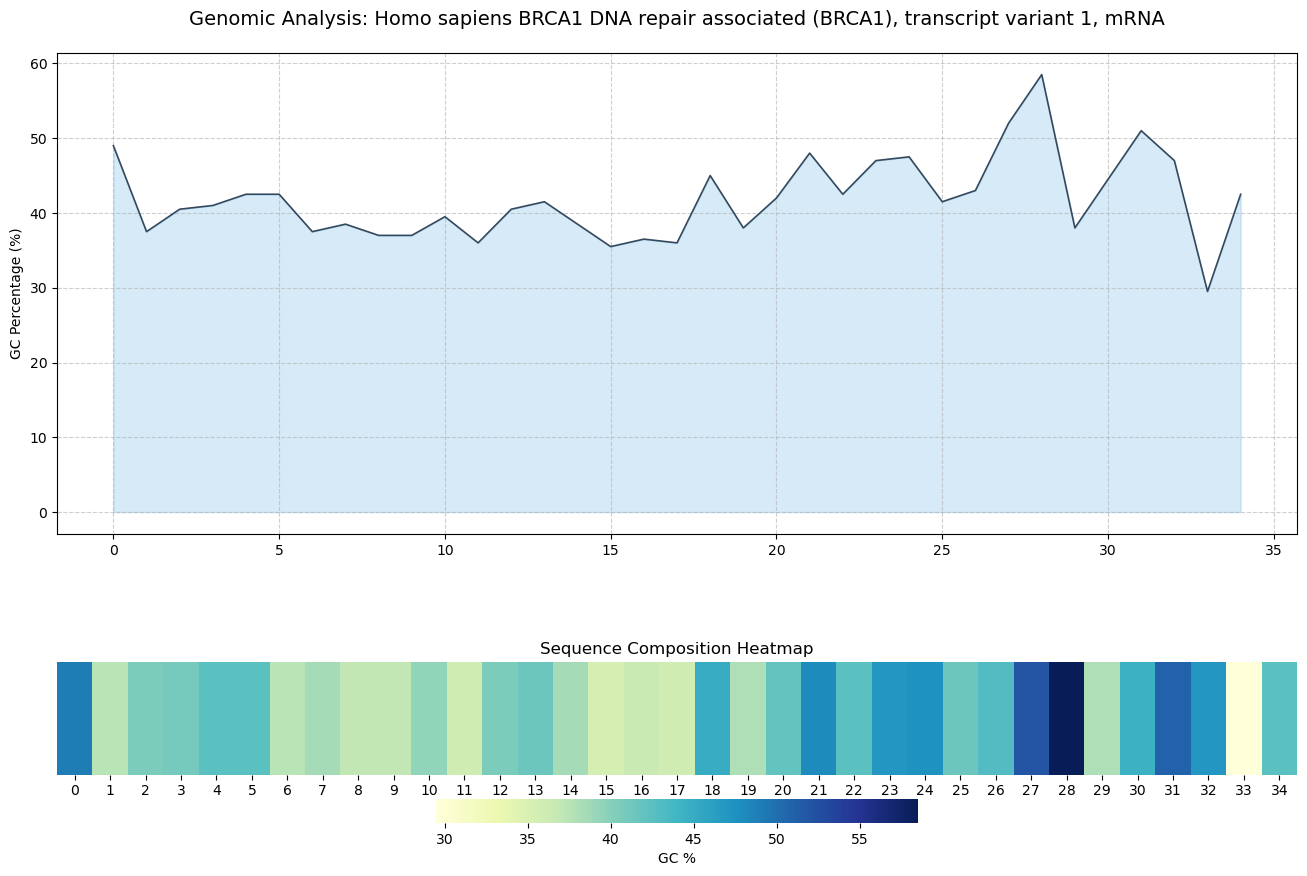

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import Entrez, SeqIO
from Bio.SeqUtils import gc_fraction
import numpy as np

class AdvancedGenomicVisualizer:
    def __init__(self, email):
        Entrez.email = email
        self.record = None
        self.sequence = None

    def fetch_data(self, accession_id):
        try:
            handle = Entrez.efetch(db="nucleotide", id=accession_id, rettype="gb", retmode="text")
            self.record = SeqIO.read(handle, "genbank")
            self.sequence = self.record.seq
            handle.close()
            return True
        except Exception as e:
            return False

    def get_gc_distribution(self, window_size=200):
        intervals = range(0, len(self.sequence) - window_size + 1, window_size)
        gc_values = [gc_fraction(self.sequence[i:i + window_size]) * 100 for i in intervals]
        return np.array(gc_values)

    def plot_genomic_landscape(self):
        gc_values = self.get_gc_distribution()
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [3, 1]})
        plt.subplots_adjust(hspace=0.4)

        ax1.plot(gc_values, color='#34495e', linewidth=1.2, label='GC Density')
        ax1.fill_between(range(len(gc_values)), gc_values, color='#3498db', alpha=0.2)
        ax1.set_title(f"Genomic Analysis: {self.record.description}", fontsize=14, pad=20)
        ax1.set_ylabel("GC Percentage (%)")
        ax1.grid(True, linestyle='--', alpha=0.6)

        heatmap_data = gc_values.reshape(1, -1)
        sns.heatmap(heatmap_data, cmap="YlGnBu", ax=ax2, cbar_kws={'label': 'GC %', 'orientation': 'horizontal'})
        ax2.set_title("Sequence Composition Heatmap", fontsize=12)
        ax2.set_yticks([])
        ax2.set_xlabel("Genomic Bin Index")

        plt.savefig("professional_genomic_report.png", dpi=300, bbox_inches='tight')
        plt.show()

if __name__ == "__main__":
    visualizer = AdvancedGenomicVisualizer("kifayataliyevaa28@gmail.com")
    if visualizer.fetch_data("NM_007294"):
        visualizer.plot_genomic_landscape()